In [1]:
import cafe

cafe.logger.setLevel("INFO")
cafe.settings.backend = "python_function" # python_function, conda, cafe_docker
cafe.settings.data_dir = "/root/PyCode/scRNA/data" # NOTE: set data directory here, or use environment variable CAFE_DATA_DIR

INFO                                                                                                                                                                                                    
             ██████╗ █████╗ ███████╗███████╗                                                                                                                                                            
           ██╔════╝██╔══██╗██╔════╝██╔════╝                                                                                                                                                             
           ██║     ███████║█████╗  █████╗                                                                                                                                                               
           ██║     ██╔══██║██╔══╝  ██╔══╝                                                                                                                                                           

## Read FateAnnData 

In [2]:
fadata = cafe.data.read_pancreas() # pancrease gloden dataset from scvelo.
fadata

AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'raw_index'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'id', 'cafe', 'filename'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'counts'
    obsp: 'distances', 'connectivities'

## Infer trajectory with scvelo/paga

In [3]:
# scvelo method 
method_name="scvelo"
method = cafe.method.FateMethod(method_name=method_name)
method.infer_trajectory(fadata, id=method_name)

INFO     |- method backend loaded: FunctionBackend:'scvelo'                                                                                                                                             
Filtered out 20801 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.
Logarithmized X.
computing neighbors
    finished (0:00:05) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities
    finished (-1:59:59) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/16 cores)


  0%|          | 0/3696 [00:00<?, ?cells/s]

    finished (0:00:07) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
WARNING  |- Both milestone_percentages and progressions are given, will only use progressions                                                                                                           
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
or is corrupted (e.g. due to subsetting). Consider recomputing with `pp.neighbors`.
computing terminal states
    identified 2 regions of root cells and 1 region of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
running PAGA using priors: ['velocity_pseudotime']
    finished (0:00:00) --> added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns)
    'p

In [4]:
# palantir method
method_name="palantir"
method = cafe.method.FateMethod(method_name=method_name)
method.infer_trajectory(fadata, id=method_name)

INFO     |- method backend loaded: FunctionBackend:'palantir'                                                                                                                                           
repreprocess finish
Sampling and flocking waypoints...
Time for determining waypoints: 0.005299703280131022 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.3544146696726481 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
palantir execute finish
INFO     |- method infer trajectory successfully: FunctionBackend:'palantir'                                                                                                                            


## Trajectory visualization

Evaluate trajectory result by visualization. `scVelo` and `Palantir` trajectory can be compared with the reference(ref) trajectory as golden standard. `scVelo` is better.

array([[<Axes: title={'center': 'ref(clusters)'}, xlabel='X_umap1', ylabel='X_umap2'>,
        <Axes: title={'center': 'scvelo(clusters)'}, xlabel='X_umap1', ylabel='X_umap2'>,
        <Axes: title={'center': 'palantir(clusters)'}, xlabel='X_umap1', ylabel='X_umap2'>]],
      dtype=object)

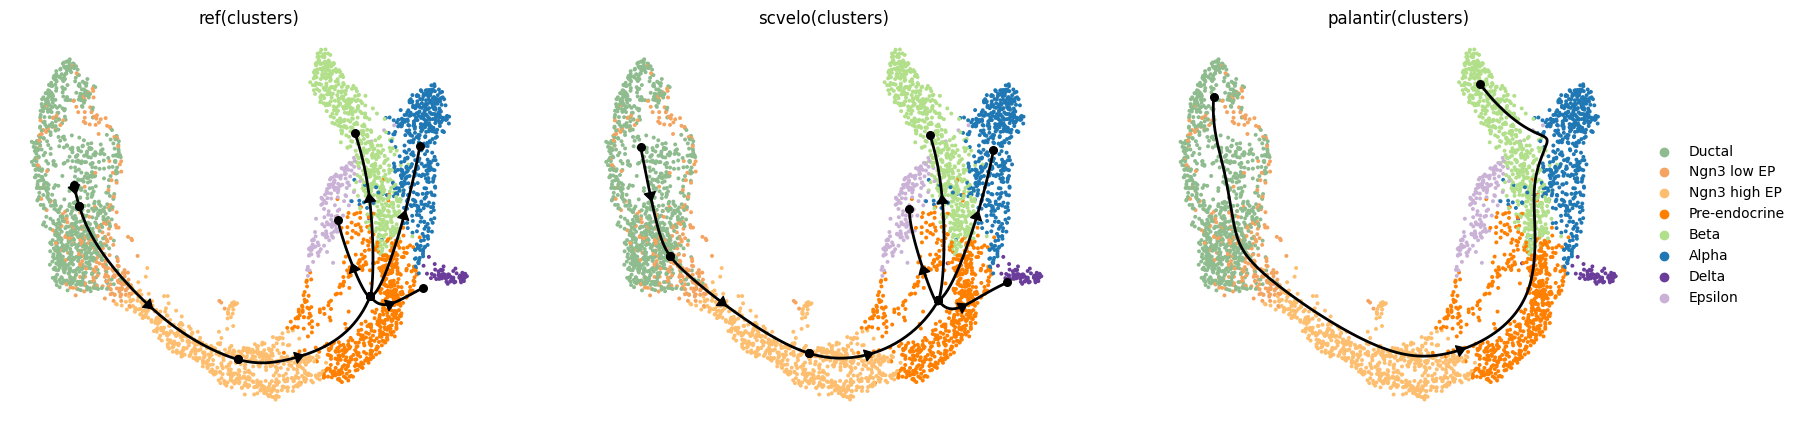

In [5]:
model_name_list = fadata.get_all_model_name()
cafe.plot.plot_trajectory(fadata, model_name=model_name_list)

In [6]:
# TODO: cellxgene-cafe web application for interactive visualization and exploration of trajectory inference results.
# fadata.launch_cellxgene()

## Metric evaluation

Evaluate trajectory result by metrics. Pseudotime metric("pseudotime_correlation") is closely between `scVelo` and `Palantir`. Other metrics(him, F1_branches, correlation) show that `scvelo` is better.

In [7]:
metrics = ["pseudotime_correlation", "him", "F1_branches", "correlation"] # "velocity_cbdir" need recalculate neighbors.
metric_df = cafe.metric.calculate_metrics(fadata, now_models=model_name_list[1:], metrics=metrics)
metric_df

,pseudotime_correlation,him,F1_branches,correlation
scvelo,0.99,0.96,1.00,0.88
palantir,0.98,0.27,0.19,0.67


## Print trajectory data

In [8]:
fadata.print_trajectory_data()

cafe
├── prior_information
│   ├── cluster → str: 'clusters'
│   ├── basis → str: 'X_umap'
│   └── start_cell → str: 'cell_1103'
├── model_name → str: 'palantir'
├── trajectory_history_dict
│   ├── ref
│   │   ├── milestone_wrapper → MilestoneWrapper: <cafe.data.fate_milestone_wrapper.MilestoneWrapper
│   │   ├── raw_wrapper_dict
│   │   ├── trajectory_embedding
│   │   │   └── X_umap
│   │   │       ├── wp_segments → DataFrame shape=(212, 9)
│   │   │       └── milestone_positions → DataFrame shape=(14, 9)
│   │   ├── waypoint_wrapper → WaypointWrapper: <cafe.data.fate_waypoint_wrapper.WaypointWrapper o
│   │   └── pseudotime_from_Ductal → list len=3696
│   ├── scvelo
│   │   ├── raw_wrapper_dict
│   │   │   ├── wrapper_type → str: 'velocity'
│   │   │   ├── velocity → ndarray shape=(3696, 2000)
│   │   │   ├── velocity_graph → csr_matrix shape=(3696, 3696)
│   │   │   ├── velocity_graph_neg → csr_matrix shape=(3696, 3696)
│   │   │   ├── neighbors
│   │   │   │   ├── distances → csr_matrix shape=(3696, 3696)
│   │   │   │   └── connectivities → csr_matrix shape=(3696, 3696)
│   │   │   ├── obs_index → Index shape=(3696,)
│   │   │   ├── var_index → Index shape=(2000,)
│   │   │   └── velocity_umap → ndarray shape=(3696, 2)
│   │   ├── milestone_wrapper → MilestoneWrapper: <cafe.data.fate_milestone_wrapper.MilestoneWrapper
│   │   ├── trajectory_embedding
│   │   │   └── X_umap
│   │   │       ├── wp_segments → DataFrame shape=(210, 9)
│   │   │       └── milestone_positions → DataFrame shape=(14, 9)
│   │   ├── waypoint_wrapper → WaypointWrapper: <cafe.data.fate_waypoint_wrapper.WaypointWrapper o
│   │   └── pseudotime_from_Ductal → list len=3696
│   └── palantir
│       ├── raw_wrapper_dict
│       │   ├── pseudotime → Series shape=(3696,)
│       │   └── wrapper_type → str: 'linear'
│       ├── milestone_wrapper → MilestoneWrapper: <cafe.data.fate_milestone_wrapper.MilestoneWrapper
│       ├── trajectory_embedding
│       │   └── X_umap
│       │       ├── wp_segments → DataFrame shape=(201, 9)
│       │       └── milestone_positions → DataFrame shape=(2, 9)
│       ├── waypoint_wrapper → WaypointWrapper: <cafe.data.fate_waypoint_wrapper.WaypointWrapper o
│       └── pseudotime_from_milestone_begin → list len=3696
└── wrapper_type → str: 'linear'

## Write h5ad file

In [9]:
fadata.write_h5ad("pancrease_fadata.h5ad")

## 